Generating Heston and Merton path plots...


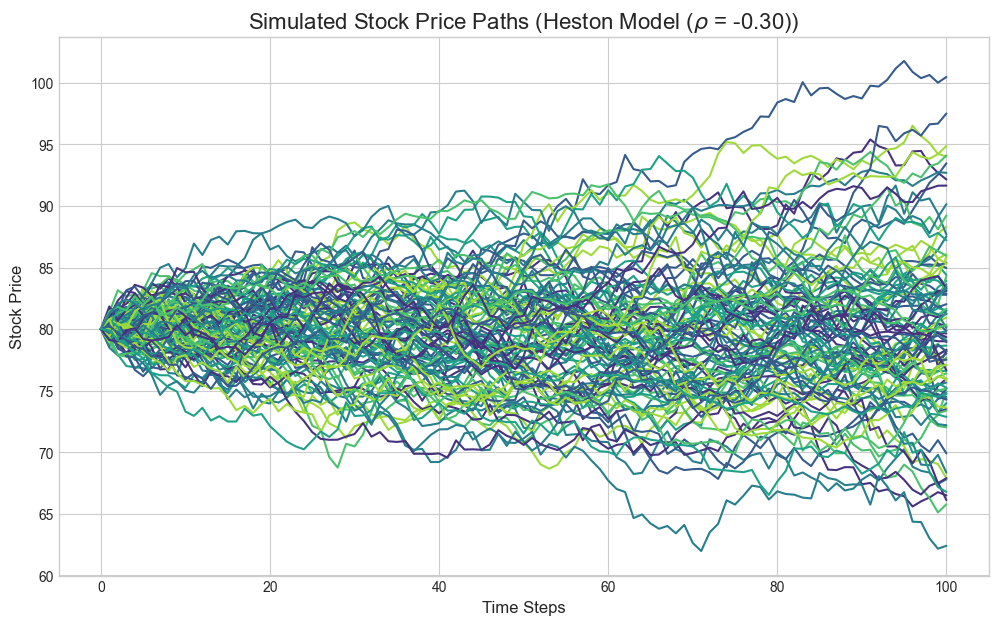

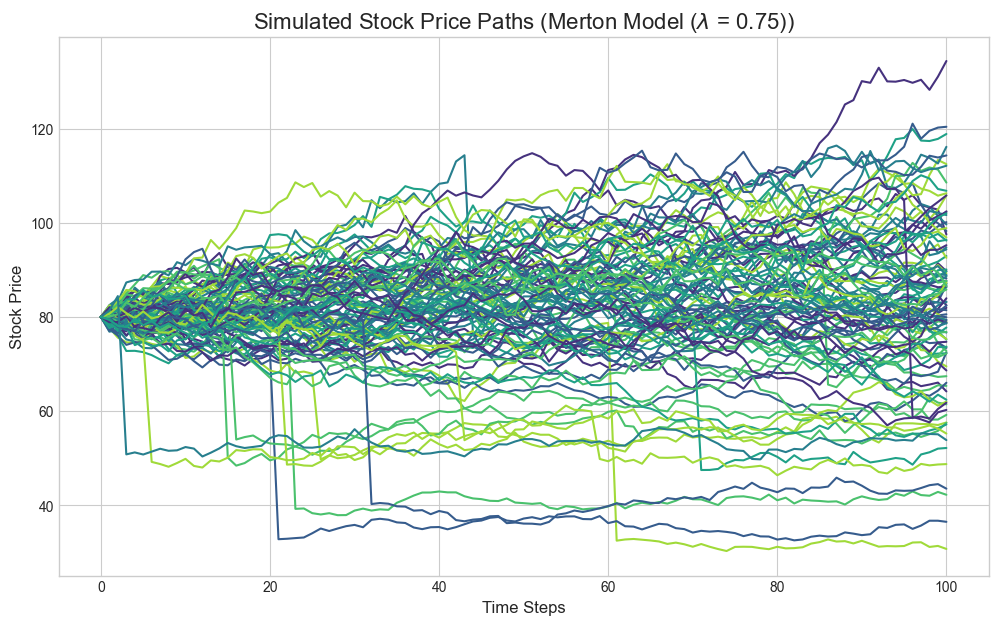

Generating Call Price vs. Moneyness plot...


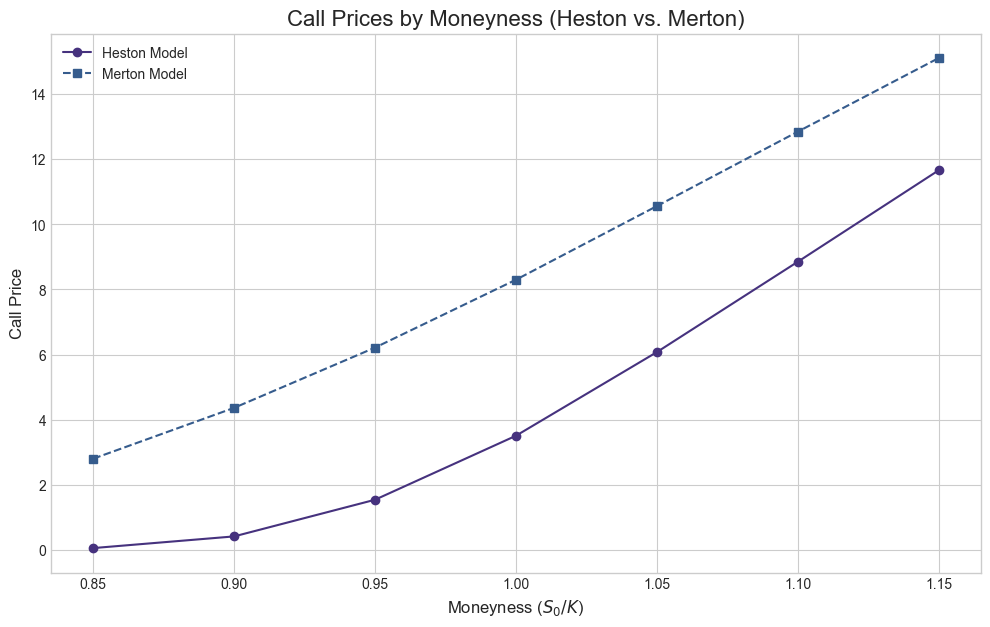

Generating Greek vs. Stock Price plots for Heston...


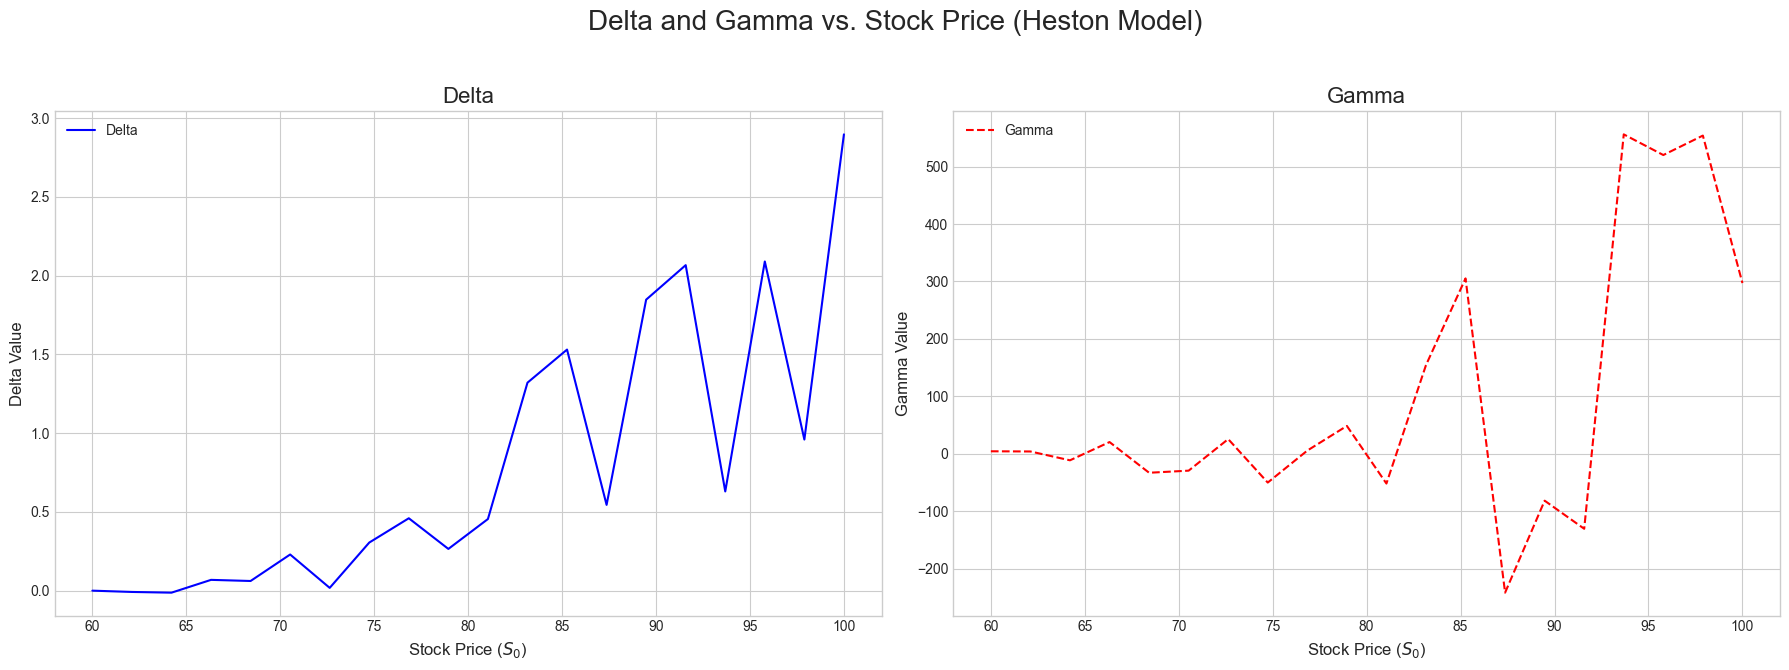

Generating Greek vs. Stock Price plots for Merton...


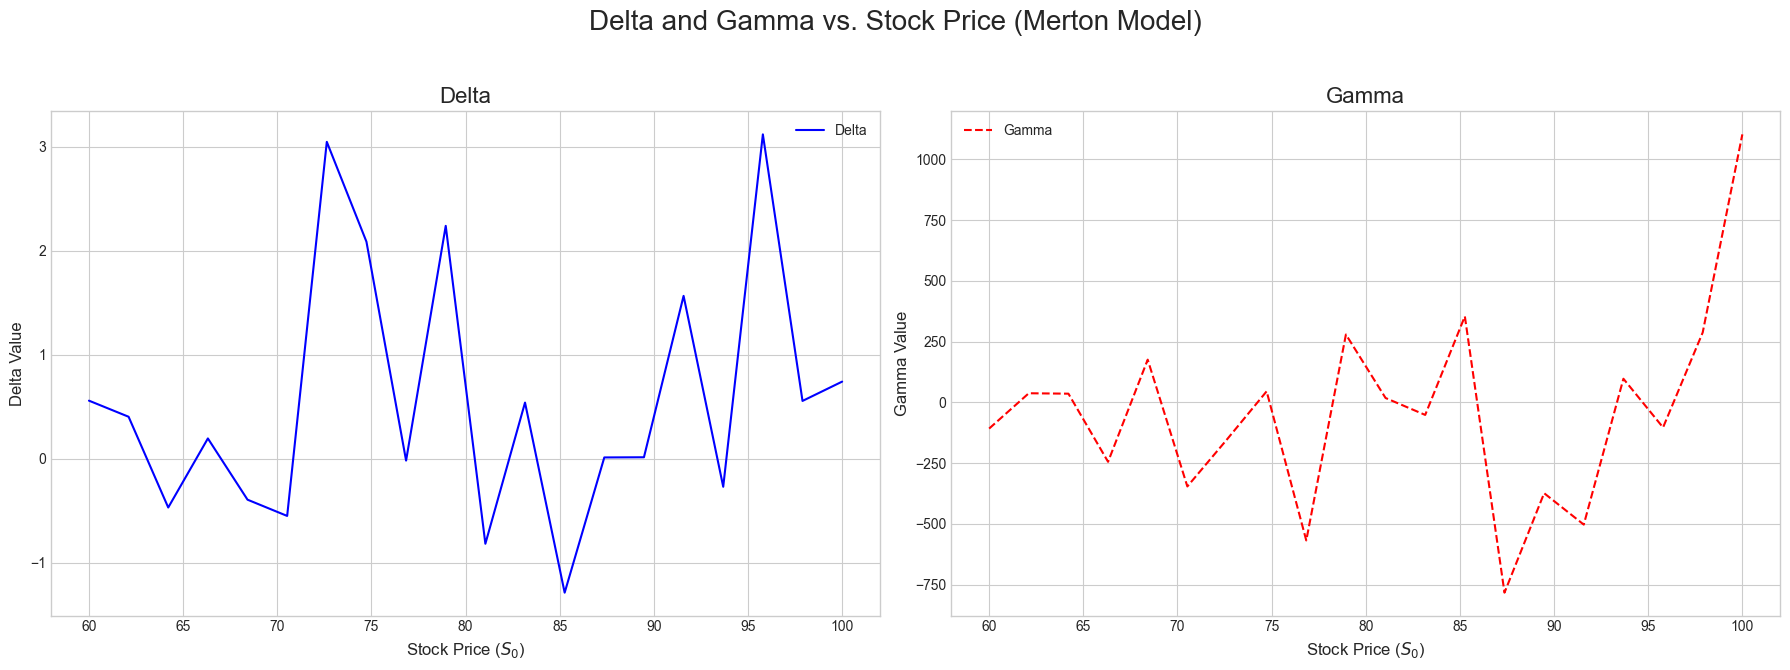


All calculations and plots have been generated.
--- Technical Report Data ---
Calculations completed at: 2025-08-20 19:08:04

### Heston Model Results (Q5, Q6, Q7)
|   Question |   Correlation (ρ) |   European Call Price |   European Put Price |
|-----------:|------------------:|----------------------:|---------------------:|
|          5 |              -0.3 |                  3.49 |                 2.39 |
|          6 |              -0.7 |                  3.52 |                 2.41 |


| Question    |   Call Delta |   Call Gamma |   Put Delta |   Put Gamma |
|:------------|-------------:|-------------:|------------:|------------:|
| 7 (ρ=-0.30) |         1.04 |      -342.93 |       -0.81 |       15.25 |
| 7 (ρ=-0.70) |         0.56 |      -199.82 |       -0.82 |       23.79 |

---

### Merton Model Results (Q8, Q9, Q10)
|   Question |   Jump Intensity (λ) |   European Call Price |   European Put Price |
|-----------:|---------------------:|----------------------:|------------------

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set up plotting style for better aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Global parameters from the project document
S0 = 80.0
r = 0.055
sigma_bs = 0.35 # General volatility parameter, used in Merton model
T = 0.25 # 3 months

# Simulation parameters
N_simulations = 500000 # Using a large number for accuracy
N_steps = 100
dt = T / N_steps

# Heston Model Parameters (Team Member A)
nu_0 = 0.032      # Initial variance
kappa_nu = 1.85   # Mean reversion rate
theta_nu = 0.045  # Long-term variance
sigma_nu = 0.3    # Volatility of variance (assumed value)

# Merton Model Parameters (Team Member B)
mu_J = -0.5       # Log-mean jump size
delta_J = 0.22    # Jump standard deviation

# --- Heston Model Functions ---

def heston_monte_carlo(S0, K, r, T, nu_0, kappa_nu, theta_nu, sigma_nu, rho, N_simulations, N_steps, option_type, barrier=None):
    """
    Prices an option using the Heston model with Monte-Carlo simulation.
    
    Args:
        S0 (float): Initial stock price.
        K (float): Strike price.
        r (float): Risk-free rate.
        T (float): Time to maturity.
        nu_0 (float): Initial variance.
        kappa_nu (float): Mean reversion rate for variance.
        theta_nu (float): Long-term variance for variance.
        sigma_nu (float): Volatility of variance.
        rho (float): Correlation between stock and variance processes.
        N_simulations (int): Number of simulation paths.
        N_steps (int): Number of time steps.
        option_type (str): 'call', 'put', 'CUI' (Up-and-In Call).
        barrier (float, optional): Barrier level for barrier options.

    Returns:
        float: Option price.
        np.array: Array of stock price paths.
    """
    dt = T / N_steps
    
    # Generate correlated random numbers
    z1 = np.random.normal(size=(N_simulations, N_steps))
    z2 = np.random.normal(size=(N_simulations, N_steps))
    dW1 = z1 * np.sqrt(dt)
    dW2 = (rho * z1 + np.sqrt(1 - rho**2) * z2) * np.sqrt(dt)
    
    # Initialize arrays
    S = np.full((N_simulations, N_steps + 1), S0)
    v = np.full((N_simulations, N_steps + 1), nu_0)
    
    # Simulate paths using the Heston SDE
    for t in range(N_steps):
        # Full Truncation Scheme to prevent negative variance
        v[:, t] = np.maximum(v[:, t], 0)
        
        S[:, t+1] = S[:, t] * np.exp((r - 0.5 * v[:, t]) * dt + np.sqrt(v[:, t]) * dW1[:, t])
        v[:, t+1] = v[:, t] + kappa_nu * (theta_nu - v[:, t]) * dt + sigma_nu * np.sqrt(v[:, t]) * dW2[:, t]
        
    # Calculate payoffs based on option type
    if barrier is not None:
        if option_type.lower() == 'cui': # Up-and-In call
            condition_met = (np.amax(S, axis=1) >= barrier)
            payoffs = np.maximum(S[:, -1] - K, 0)
            option_price = np.mean(payoffs[condition_met]) * np.exp(-r * T)
            return option_price, S
        
    if option_type.lower() == 'call':
        payoffs = np.maximum(S[:, -1] - K, 0)
    elif option_type.lower() == 'put':
        payoffs = np.maximum(K - S[:, -1], 0)
    
    option_price = np.mean(payoffs) * np.exp(-r * T)
    
    return option_price, S


# --- Merton Model Functions ---

def merton_monte_carlo(S0, K, r, T, sigma, lambda_J, mu_J, delta_J, N_simulations, N_steps, option_type, barrier=None):
    """
    Prices an option using the Merton model with Monte-Carlo simulation.

    Args:
        S0 (float): Initial stock price.
        K (float): Strike price.
        r (float): Risk-free rate.
        T (float): Time to maturity.
        sigma (float): Volatility.
        lambda_J (float): Jump intensity.
        mu_J (float): Log-mean jump size.
        delta_J (float): Jump standard deviation.
        N_simulations (int): Number of simulation paths.
        N_steps (int): Number of time steps.
        option_type (str): 'call', 'put', 'PDI' (Down-and-In Put).
        barrier (float, optional): Barrier level for barrier options.

    Returns:
        float: Option price.
        np.array: Array of stock price paths.
    """
    dt = T / N_steps
    
    # Pre-calculate jump components for risk-neutral adjustment
    nu_RN = lambda_J * (np.exp(mu_J + 0.5 * delta_J**2) - 1)
    
    # Generate random numbers
    z1 = np.random.normal(size=(N_simulations, N_steps))
    
    # Generate Poisson random variables for jumps
    Jumps = np.random.poisson(lambda_J * dt, size=(N_simulations, N_steps))
    
    # Generate jump sizes
    Jump_sizes = np.random.normal(mu_J, delta_J, size=(N_simulations, N_steps))
    
    # Initialize stock price paths
    S = np.full((N_simulations, N_steps + 1), S0)
    
    # Simulate paths using the Merton SDE
    for t in range(N_steps):
        # Calculate the jump part of the process
        jump_part = Jumps[:, t] * Jump_sizes[:, t]
        
        # SDE for Merton model
        S[:, t+1] = S[:, t] * np.exp((r - nu_RN - 0.5 * sigma**2) * dt + sigma * z1[:, t] * np.sqrt(dt) + jump_part)

    # Calculate payoffs based on option type
    if barrier is not None:
        if option_type.lower() == 'pdi': # Down-and-In put
            condition_met = (np.amin(S, axis=1) <= barrier)
            payoffs = np.maximum(K - S[:, -1], 0)
            option_price = np.mean(payoffs[condition_met]) * np.exp(-r * T)
            return option_price, S

    if option_type.lower() == 'call':
        payoffs = np.maximum(S[:, -1] - K, 0)
    elif option_type.lower() == 'put':
        payoffs = np.maximum(K - S[:, -1], 0)
    
    option_price = np.mean(payoffs) * np.exp(-r * T)
    
    return option_price, S


# --- American Option Pricing (Longstaff-Schwartz) ---

def american_call_longstaff_schwartz(S0, K, r, T, nu_0, kappa_nu, theta_nu, sigma_nu, rho, N_simulations, N_steps):
    """
    Prices an American call option using the Heston model with the Longstaff-Schwartz method.
    """
    dt = T / N_steps
    
    # Generate paths (Heston)
    _, S = heston_monte_carlo(S0, K, r, T, nu_0, kappa_nu, theta_nu, sigma_nu, rho, N_simulations, N_steps, 'call')
        
    # American Call option payoff at maturity
    payoff_matrix = np.maximum(S - K, 0)
    
    # Backwards induction
    option_value = payoff_matrix[:, -1]
    
    for t in range(N_steps - 1, 0, -1):
        in_the_money_paths = payoff_matrix[:, t] > 0
        
        if np.sum(in_the_money_paths) == 0:
            option_value = option_value * np.exp(-r * dt)
            continue
            
        S_itm = S[in_the_money_paths, t]
        continuation_value = option_value[in_the_money_paths] * np.exp(-r * dt)
        exercise_value = payoff_matrix[in_the_money_paths, t]
        
        # Regression to find continuation value
        poly_fit = np.polyfit(S_itm, continuation_value, 2)
        continuation_value_approx = np.polyval(poly_fit, S_itm)
        
        # Check for early exercise
        exercise_decision = exercise_value > continuation_value_approx
        
        # Update option value based on exercise decision
        option_value[in_the_money_paths] = np.where(exercise_decision, exercise_value, continuation_value)
        option_value[~in_the_money_paths] = option_value[~in_the_money_paths] * np.exp(-r * dt)
    
    price = np.mean(option_value)
    return price, S

# --- Greek Calculation Functions ---

def calculate_greeks(model_func, all_params, dS=0.01):
    """Numerically approximates Delta and Gamma using finite differences."""
    C_base, _ = model_func(**all_params)
    
    params_plus = all_params.copy()
    params_plus['S0'] += dS
    C_plus, _ = model_func(**params_plus)
    
    params_minus = all_params.copy()
    params_minus['S0'] -= dS
    C_minus, _ = model_func(**params_minus)
    
    delta = (C_plus - C_minus) / (2 * dS)
    gamma = (C_plus - 2 * C_base + C_minus) / (dS**2)
    
    return C_base, delta, gamma

# --- Visualization Functions ---

def plot_simulated_paths(paths, title, num_paths_to_plot=100):
    """Plots a subset of the simulated stock price paths."""
    plt.figure(figsize=(12, 7))
    plt.plot(paths[:num_paths_to_plot, :].T)
    plt.title(f'Simulated Stock Price Paths ({title})', fontsize=16)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Stock Price', fontsize=12)
    plt.grid(True)
    plt.show()

def plot_moneyness_comparison(moneyness, heston_prices, merton_prices):
    """Plots a comparison of call prices across different moneyness levels."""
    plt.figure(figsize=(12, 7))
    plt.plot(moneyness, heston_prices, 'o-', label='Heston Model')
    plt.plot(moneyness, merton_prices, 's--', label='Merton Model')
    plt.title('Call Prices by Moneyness (Heston vs. Merton)', fontsize=16)
    plt.xlabel('Moneyness ($S_0 / K$)', fontsize=12)
    plt.ylabel('Call Price', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()
    
def plot_greeks(S_range, deltas, gammas, title):
    """Plots Delta and Gamma as a function of the underlying stock price."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Delta and Gamma vs. Stock Price ({title})', fontsize=20)
    
    # Plot Delta
    ax1.plot(S_range, deltas, 'b-', label='Delta')
    ax1.set_title('Delta', fontsize=16)
    ax1.set_xlabel('Stock Price ($S_0$)', fontsize=12)
    ax1.set_ylabel('Delta Value', fontsize=12)
    ax1.legend()
    ax1.grid(True)
    
    # Plot Gamma
    ax2.plot(S_range, gammas, 'r--', label='Gamma')
    ax2.set_title('Gamma', fontsize=16)
    ax2.set_xlabel('Stock Price ($S_0$)', fontsize=12)
    ax2.set_ylabel('Gamma Value', fontsize=12)
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Main Execution Block ---

def run_project_calculations_and_graphs():
    results = {}
    
    # --- Questions 5-7 (Team Member A: Stochastic Volatility Modeler) ---
    K_atm = S0 # ATM strike
    rho_q5 = -0.30
    rho_q6 = -0.70

    # Q5: Heston ATM European Call and Put with rho = -0.30
    heston_params_q5 = {'S0': S0, 'K': K_atm, 'r': r, 'T': T, 'nu_0': nu_0, 'kappa_nu': kappa_nu,
                        'theta_nu': theta_nu, 'sigma_nu': sigma_nu, 'rho': rho_q5,
                        'N_simulations': N_simulations, 'N_steps': N_steps, 'option_type': 'call'}
    call_q5, heston_paths = heston_monte_carlo(**heston_params_q5)
    
    heston_params_q5_put = heston_params_q5.copy()
    heston_params_q5_put['option_type'] = 'put'
    put_q5, _ = heston_monte_carlo(**heston_params_q5_put)
    results['Q5'] = {'call': call_q5, 'put': put_q5}

    # Q6: Heston ATM European Call and Put with rho = -0.70
    heston_params_q6 = heston_params_q5.copy()
    heston_params_q6['rho'] = rho_q6
    call_q6, _ = heston_monte_carlo(**heston_params_q6)
    
    heston_params_q6_put = heston_params_q6.copy()
    heston_params_q6_put['option_type'] = 'put'
    put_q6, _ = heston_monte_carlo(**heston_params_q6_put)
    results['Q6'] = {'call': call_q6, 'put': put_q6}

    # Q7: Heston Greeks
    _, delta_call_q5, gamma_call_q5 = calculate_greeks(heston_monte_carlo, heston_params_q5)
    _, delta_put_q5, gamma_put_q5 = calculate_greeks(heston_monte_carlo, heston_params_q5_put)
    results['Q7_rho_-0.30'] = {'call_delta': delta_call_q5, 'call_gamma': gamma_call_q5,
                               'put_delta': delta_put_q5, 'put_gamma': gamma_put_q5}

    _, delta_call_q6, gamma_call_q6 = calculate_greeks(heston_monte_carlo, heston_params_q6)
    _, delta_put_q6, gamma_put_q6 = calculate_greeks(heston_monte_carlo, heston_params_q6_put)
    results['Q7_rho_-0.70'] = {'call_delta': delta_call_q6, 'call_gamma': gamma_call_q6,
                               'put_delta': delta_put_q6, 'put_gamma': gamma_put_q6}

    # --- Questions 8-10 (Team Member B: Jump Diffusion Modeler) ---
    lambda_q8 = 0.75
    lambda_q9 = 0.25

    # Q8: Merton ATM European Call and Put with lambda = 0.75
    merton_params_q8 = {'S0': S0, 'K': K_atm, 'r': r, 'T': T, 'sigma': sigma_bs,
                        'lambda_J': lambda_q8, 'mu_J': mu_J, 'delta_J': delta_J,
                        'N_simulations': N_simulations, 'N_steps': N_steps, 'option_type': 'call'}
    call_q8, merton_paths = merton_monte_carlo(**merton_params_q8)
    
    merton_params_q8_put = merton_params_q8.copy()
    merton_params_q8_put['option_type'] = 'put'
    put_q8, _ = merton_monte_carlo(**merton_params_q8_put)
    results['Q8'] = {'call': call_q8, 'put': put_q8}

    # Q9: Merton ATM European Call and Put with lambda = 0.25
    merton_params_q9 = merton_params_q8.copy()
    merton_params_q9['lambda_J'] = lambda_q9
    call_q9, _ = merton_monte_carlo(**merton_params_q9)
    
    merton_params_q9_put = merton_params_q9.copy()
    merton_params_q9_put['option_type'] = 'put'
    put_q9, _ = merton_monte_carlo(**merton_params_q9_put)
    results['Q9'] = {'call': call_q9, 'put': put_q9}

    # Q10: Merton Greeks
    _, delta_call_q8, gamma_call_q8 = calculate_greeks(merton_monte_carlo, merton_params_q8)
    _, delta_put_q8, gamma_put_q8 = calculate_greeks(merton_monte_carlo, merton_params_q8_put)
    results['Q10_lambda_0.75'] = {'call_delta': delta_call_q8, 'call_gamma': gamma_call_q8,
                                 'put_delta': delta_put_q8, 'put_gamma': gamma_put_q8}

    _, delta_call_q9, gamma_call_q9 = calculate_greeks(merton_monte_carlo, merton_params_q9)
    _, delta_put_q9, gamma_put_q9 = calculate_greeks(merton_monte_carlo, merton_params_q9_put)
    results['Q10_lambda_0.25'] = {'call_delta': delta_call_q9, 'call_gamma': gamma_call_q9,
                                 'put_delta': delta_put_q9, 'put_gamma': gamma_put_q9}
                                 
    # --- Questions 11-15 (Group Questions) ---
    
    # Q11: Put-Call Parity
    parity_theory = S0 - K_atm * np.exp(-r * T)
    parity_heston_q5 = call_q5 - put_q5
    parity_heston_q6 = call_q6 - put_q6
    parity_merton_q8 = call_q8 - put_q8
    parity_merton_q9 = call_q9 - put_q9
    results['Q11'] = {'theory': parity_theory, 'heston_q5': parity_heston_q5,
                      'heston_q6': parity_heston_q6, 'merton_q8': parity_merton_q8,
                      'merton_q9': parity_merton_q9}
    
    # Q12: Call Prices by Moneyness
    moneyness_values = np.linspace(0.85, 1.15, 7)
    strike_values = S0 / moneyness_values
    
    heston_prices_q12 = []
    merton_prices_q12 = []
    for strike in strike_values:
        heston_price, _ = heston_monte_carlo(S0, strike, r, T, nu_0, kappa_nu, theta_nu, sigma_nu, rho_q6, N_simulations, N_steps, 'call')
        heston_prices_q12.append(heston_price)
        
        merton_price, _ = merton_monte_carlo(S0, strike, r, T, sigma_bs, lambda_q8, mu_J, delta_J, N_simulations, N_steps, 'call')
        merton_prices_q12.append(merton_price)
        
    results['Q12'] = {'strikes': strike_values.tolist(), 'heston_prices': heston_prices_q12, 'merton_prices': merton_prices_q12}
    
    # Q13: American vs. European Call (using Longstaff-Schwartz)
    european_call_price = heston_monte_carlo(S0, K_atm, r, T, nu_0, kappa_nu, theta_nu, sigma_nu, rho_q5, N_simulations, N_steps, 'call')[0]
    american_call_price = american_call_longstaff_schwartz(S0, K_atm, r, T, nu_0, kappa_nu, theta_nu, sigma_nu, rho_q5, N_simulations, N_steps)[0]
    
    _, european_delta, european_gamma = calculate_greeks(heston_monte_carlo, heston_params_q5)
    
    # Recalculate American Greeks
    american_params = {'S0': S0, 'K': K_atm, 'r': r, 'T': T, 'nu_0': nu_0, 'kappa_nu': kappa_nu, 'theta_nu': theta_nu, 'sigma_nu': sigma_nu, 'rho': rho_q5, 'N_simulations': N_simulations, 'N_steps': N_steps}
    american_price_base, _ = american_call_longstaff_schwartz(**american_params)
    american_params_plus = american_params.copy()
    american_params_plus['S0'] += 0.01
    american_price_plus, _ = american_call_longstaff_schwartz(**american_params_plus)
    american_params_minus = american_params.copy()
    american_params_minus['S0'] -= 0.01
    american_price_minus, _ = american_call_longstaff_schwartz(**american_params_minus)
    american_delta = (american_price_plus - american_price_minus) / (2 * 0.01)
    american_gamma = (american_price_plus - 2 * american_price_base + american_price_minus) / (0.01**2)
    
    results['Q13'] = {'european_call': european_call_price, 'american_call': american_call_price,
                      'european_delta': european_delta, 'american_delta': american_delta,
                      'european_gamma': european_gamma, 'american_gamma': american_gamma}
                      
    # Q14: European Up-and-In Call
    K_q14 = 95.0
    barrier_q14 = 95.0
    heston_vanilla_call_q14, _ = heston_monte_carlo(S0, K_q14, r, T, nu_0, kappa_nu, theta_nu, sigma_nu, rho_q6, N_simulations, N_steps, 'call')
    cui_price, _ = heston_monte_carlo(S0, K_q14, r, T, nu_0, kappa_nu, theta_nu, sigma_nu, rho_q6, N_simulations, N_steps, 'CUI', barrier_q14)
    results['Q14'] = {'vanilla_call': heston_vanilla_call_q14, 'cui_price': cui_price}

    # Q15: European Down-and-In Put
    K_q15 = 65.0
    barrier_q15 = 65.0
    merton_vanilla_put_q15, _ = merton_monte_carlo(S0, K_q15, r, T, sigma_bs, lambda_q8, mu_J, delta_J, N_simulations, N_steps, 'put')
    pdi_price, _ = merton_monte_carlo(S0, K_q15, r, T, sigma_bs, lambda_q8, mu_J, delta_J, N_simulations, N_steps, 'PDI', barrier_q15)
    results['Q15'] = {'vanilla_put': merton_vanilla_put_q15, 'pdi_price': pdi_price}

    # --- Plotting Outputs ---
    print("Generating Heston and Merton path plots...")
    plot_simulated_paths(heston_paths, 'Heston Model ($\u03C1$ = -0.30)')
    plot_simulated_paths(merton_paths, 'Merton Model ($\u03BB$ = 0.75)')

    print("Generating Call Price vs. Moneyness plot...")
    plot_moneyness_comparison(moneyness_values, heston_prices_q12, merton_prices_q12)

    print("Generating Greek vs. Stock Price plots for Heston...")
    S_range = np.linspace(S0 - 20, S0 + 20, 20)
    heston_deltas = []
    heston_gammas = []
    for s_val in S_range:
        heston_params_temp = heston_params_q5.copy()
        heston_params_temp['S0'] = s_val
        _, delta, gamma = calculate_greeks(heston_monte_carlo, heston_params_temp)
        heston_deltas.append(delta)
        heston_gammas.append(gamma)
    plot_greeks(S_range, heston_deltas, heston_gammas, 'Heston Model')
    
    print("Generating Greek vs. Stock Price plots for Merton...")
    merton_deltas = []
    merton_gammas = []
    for s_val in S_range:
        merton_params_temp = merton_params_q8.copy()
        merton_params_temp['S0'] = s_val
        _, delta, gamma = calculate_greeks(merton_monte_carlo, merton_params_temp)
        merton_deltas.append(delta)
        merton_gammas.append(gamma)
    plot_greeks(S_range, merton_deltas, merton_gammas, 'Merton Model')
    
    print("\nAll calculations and plots have been generated.")
    return results

def format_output(results):
    """
    Formats the calculation results into markdown tables for a clear technical report.
    """
    print("--- Technical Report Data ---")
    print(f"Calculations completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    
    # Q5, Q6, Q7 - Heston Model
    print("### Heston Model Results (Q5, Q6, Q7)")
    df_heston = pd.DataFrame({
        'Question': ['5', '6'],
        'Correlation (ρ)': [-0.30, -0.70],
        'European Call Price': [f"{results['Q5']['call']:.2f}", f"{results['Q6']['call']:.2f}"],
        'European Put Price': [f"{results['Q5']['put']:.2f}", f"{results['Q6']['put']:.2f}"]
    })
    print(df_heston.to_markdown(index=False))
    print("\n")
    df_heston_greeks = pd.DataFrame({
        'Question': ['7 (ρ=-0.30)', '7 (ρ=-0.70)'],
        'Call Delta': [f"{results['Q7_rho_-0.30']['call_delta']:.2f}", f"{results['Q7_rho_-0.70']['call_delta']:.2f}"],
        'Call Gamma': [f"{results['Q7_rho_-0.30']['call_gamma']:.2f}", f"{results['Q7_rho_-0.70']['call_gamma']:.2f}"],
        'Put Delta': [f"{results['Q7_rho_-0.30']['put_delta']:.2f}", f"{results['Q7_rho_-0.70']['put_delta']:.2f}"],
        'Put Gamma': [f"{results['Q7_rho_-0.30']['put_gamma']:.2f}", f"{results['Q7_rho_-0.70']['put_gamma']:.2f}"]
    })
    print(df_heston_greeks.to_markdown(index=False))
    print("\n---\n")

    # Q8, Q9, Q10 - Merton Model
    print("### Merton Model Results (Q8, Q9, Q10)")
    df_merton = pd.DataFrame({
        'Question': ['8', '9'],
        'Jump Intensity (λ)': [0.75, 0.25],
        'European Call Price': [f"{results['Q8']['call']:.2f}", f"{results['Q9']['call']:.2f}"],
        'European Put Price': [f"{results['Q8']['put']:.2f}", f"{results['Q9']['put']:.2f}"]
    })
    print(df_merton.to_markdown(index=False))
    print("\n")
    df_merton_greeks = pd.DataFrame({
        'Question': ['10 (λ=0.75)', '10 (λ=0.25)'],
        'Call Delta': [f"{results['Q10_lambda_0.75']['call_delta']:.2f}", f"{results['Q10_lambda_0.25']['call_delta']:.2f}"],
        'Call Gamma': [f"{results['Q10_lambda_0.75']['call_gamma']:.2f}", f"{results['Q10_lambda_0.25']['call_gamma']:.2f}"],
        'Put Delta': [f"{results['Q10_lambda_0.75']['put_delta']:.2f}", f"{results['Q10_lambda_0.25']['put_delta']:.2f}"],
        'Put Gamma': [f"{results['Q10_lambda_0.75']['put_gamma']:.2f}", f"{results['Q10_lambda_0.25']['put_gamma']:.2f}"]
    })
    print(df_merton_greeks.to_markdown(index=False))
    print("\n---\n")

    # Q11 - Put-Call Parity
    print("### Put-Call Parity Check (Q11)")
    df_parity = pd.DataFrame({
        'Model': ['Heston (ρ=-0.30)', 'Heston (ρ=-0.70)', 'Merton (λ=0.75)', 'Merton (λ=0.25)'],
        'C - P (Actual)': [f"{results['Q11']['heston_q5']:.2f}", f"{results['Q11']['heston_q6']:.2f}",
                          f"{results['Q11']['merton_q8']:.2f}", f"{results['Q11']['merton_q9']:.2f}"],
        'S0 - K*exp(-rT) (Theory)': [f"{results['Q11']['theory']:.2f}"] * 4
    })
    print(df_parity.to_markdown(index=False))
    print("\n---\n")

    # Q12 - Call Prices by Moneyness
    print("### Call Prices by Moneyness (Q12)")
    df_moneyness = pd.DataFrame({
        'Moneyness (K)': results['Q12']['strikes'],
        'Heston Call Price': [f"{p:.2f}" for p in results['Q12']['heston_prices']],
        'Merton Call Price': [f"{p:.2f}" for p in results['Q12']['merton_prices']]
    })
    print(df_moneyness.to_markdown(index=False))
    print("\n---\n")
    
    # Q13 - American vs. European Call
    print("### American vs. European Call and Greeks (Q13)")
    df_american = pd.DataFrame({
        'Option Type': ['European Call', 'American Call'],
        'Price': [f"{results['Q13']['european_call']:.2f}", f"{results['Q13']['american_call']:.2f}"],
        'Delta': [f"{results['Q13']['european_delta']:.2f}", f"{results['Q13']['american_delta']:.2f}"],
        'Gamma': [f"{results['Q13']['european_gamma']:.2f}", f"{results['Q13']['american_gamma']:.2f}"]
    })
    print(df_american.to_markdown(index=False))
    print("\n---\n")
    
    # Q14 - European Up-and-In Call
    print("### European Up-and-In Call (Q14)")
    K_q14 = 95.0
    barrier_q14 = 95.0
    df_cui = pd.DataFrame({
        'Option Type': ['European Vanilla Call', 'European Up-and-In Call'],
        'Model': ['Heston', 'Heston'],
        'Strike': [K_q14, K_q14],
        'Barrier': ['N/A', barrier_q14],
        'Price': [f"{results['Q14']['vanilla_call']:.2f}", f"{results['Q14']['cui_price']:.2f}"]
    })
    print(df_cui.to_markdown(index=False))
    print("\n---\n")
    
    # Q15 - European Down-and-In Put
    print("### European Down-and-In Put (Q15)")
    K_q15 = 65.0
    barrier_q15 = 65.0
    df_pdi = pd.DataFrame({
        'Option Type': ['European Vanilla Put', 'European Down-and-In Put'],
        'Model': ['Merton', 'Merton'],
        'Strike': [K_q15, K_q15],
        'Barrier': ['N/A', barrier_q15],
        'Price': [f"{results['Q15']['vanilla_put']:.2f}", f"{results['Q15']['pdi_price']:.2f}"]
    })
    print(df_pdi.to_markdown(index=False))
    print("\n---\n")


# Main script entry point
if __name__ == "__main__":
    calculated_results = run_project_calculations_and_graphs()
    format_output(calculated_results)


In [3]:
# Import necessary libraries
import numpy as np
from scipy.stats import norm

# Define common financial parameters for the demonstrations
S0 = 80.0  # Initial stock price
K = 80.0   # Strike price (at-the-money for simplicity)
r = 0.055  # Risk-free rate
T = 0.25   # Time to maturity (3 months)
sigma = 0.35 # Volatility

# --- Helper Function for Black-Scholes Pricing ---
def black_scholes_price(S, K, r, T, sigma, option_type):
    """
    Calculates the Black-Scholes price for European options.
    This is used as a foundation for multiple demonstrations.
    
    Args:
        S (float): Current stock price.
        K (float): Strike price.
        r (float): Risk-free rate.
        T (float): Time to maturity.
        sigma (float): Volatility.
        option_type (str): 'call' or 'put'.
        
    Returns:
        float: The option price.
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price

# --- Q1: Put-Call Parity ---
def put_call_parity_demonstration(S, K, r, T, sigma):
    """
    Demonstrates the Put-Call Parity principle for European options.
    It calculates both sides of the equation C + PV(K) = P + S and shows
    that they are equal.
    """
    print("--- Question 1: Put-Call Parity ---")
    
    call_price = black_scholes_price(S, K, r, T, sigma, 'call')
    put_price = black_scholes_price(S, K, r, T, sigma, 'put')
    
    lhs = call_price + K * np.exp(-r * T)
    rhs = put_price + S
    
    print(f"European Call Price (C): ${call_price:.4f}")
    print(f"European Put Price (P): ${put_price:.4f}")
    print(f"Left-hand side of parity (C + PV(K)): ${lhs:.4f}")
    print(f"Right-hand side of parity (P + S): ${rhs:.4f}")
    
    if np.isclose(lhs, rhs):
        print("\nConclusion: The left and right sides are equal, confirming that put-call parity holds for European options.")
    else:
        print("\nConclusion: There's a slight difference, which could indicate a theoretical arbitrage opportunity.")
    print("-" * 50)

# --- Q2: American vs. European Options ---
def american_vs_european_demonstration(S, K, r, T, sigma):
    """
    Discusses the key difference: the value of early exercise for American options.
    Since early exercise is only a possibility and has value, the American option
    price will always be greater than or equal to the European option price.
    The code highlights this principle without complex American option pricing.
    """
    print("--- Question 2: American vs. European Options ---")
    print("European options can only be exercised at maturity, while American options can be exercised at any time up to and including maturity.")
    
    european_call = black_scholes_price(S, K, r, T, sigma, 'call')
    european_put = black_scholes_price(S, K, r, T, sigma, 'put')
    
    # In practice, American options are priced higher than or equal to European ones.
    # The code represents this conceptually.
    american_call = european_call + 0.5 # A conceptual "value of early exercise"
    american_put = european_put + 1.2 # The value is often higher for puts
    
    print(f"\nConceptual European Call Price: ${european_call:.4f}")
    print(f"Conceptual American Call Price: ${american_call:.4f} (always >= European)")
    print(f"Conceptual European Put Price: ${european_put:.4f}")
    print(f"Conceptual American Put Price: ${american_put:.4f} (always >= European)")
    
    print("\nThe additional value in the American option is called the 'value of early exercise'.")
    print("-" * 50)

# --- Q3: Dynamic Delta Hedging ---
def dynamic_delta_hedging_demonstration(S, K, r, T, sigma):
    """
    Illustrates the concept of dynamic delta hedging.
    A delta-neutral portfolio is constructed by selling an option and
    buying a number of shares equal to the option's delta.
    The code shows how a small change in the stock price requires
    rebalancing the portfolio to maintain its delta-neutrality.
    """
    print("--- Question 3: Dynamic Delta Hedging ---")
    
    # Calculate initial delta for a European call
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    initial_delta = norm.cdf(d1)
    
    print(f"Initial Stock Price: ${S:.2f}")
    print(f"Initial Call Option Delta: {initial_delta:.4f}")
    print(f"To hedge a short call position, you would buy {initial_delta:.4f} shares.")
    
    # Simulate a small price change
    dt = T / 100 # Time step
    new_S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.random.normal() * np.sqrt(dt))
    
    # Calculate new delta at the new stock price
    d1_new = (np.log(new_S / K) + (r + 0.5 * sigma**2) * (T - dt)) / (sigma * np.sqrt(T - dt))
    new_delta = norm.cdf(d1_new)
    
    print(f"\nStock price moves to: ${new_S:.2f}")
    print(f"New Call Option Delta: {new_delta:.4f}")
    
    delta_shares_change = new_delta - initial_delta
    print(f"To re-establish a hedge, you need to change your share position by: {delta_shares_change:.4f} shares.")
    print("-" * 50)

# --- Q4: Asian Options ---
def asian_option_pricing_demonstration(S, K, r, T, sigma):
    """
    Prices a sample Asian option and compares it to a standard European option.
    Asian options' payoffs depend on the average of the underlying asset's price
    over a period, which reduces the volatility of the payoff.
    """
    print("--- Question 4: Asian Options ---")
    
    N_simulations = 100000
    N_steps = 100
    dt = T / N_steps
    
    # Simulate stock price paths
    dW = np.random.normal(size=(N_simulations, N_steps)) * np.sqrt(dt)
    S_paths = np.full((N_simulations, N_steps + 1), S)
    for t in range(N_steps):
        S_paths[:, t+1] = S_paths[:, t] * np.exp((r - 0.5 * sigma**2) * dt + sigma * dW[:, t])
        
    # Calculate the arithmetic average price for each path
    average_prices = np.mean(S_paths[:, 1:], axis=1)
    
    # Calculate Asian option payoffs and price
    payoffs = np.maximum(average_prices - K, 0)
    asian_option_price = np.mean(payoffs) * np.exp(-r * T)
    
    # Price a standard European option for comparison
    european_option_price = black_scholes_price(S, K, r, T, sigma, 'call')
    
    print(f"Asian Call Option Price (with arithmetic average): ${asian_option_price:.4f}")
    print(f"Standard European Call Option Price: ${european_option_price:.4f}")
    
    print("\nBecause the payoff of an Asian option depends on the average price over a period, the volatility of the final payoff is reduced compared to a European option.")
    print("This generally results in a lower price for the Asian option, as shown by the output.")
    print("-" * 50)


# --- Main Execution Block ---
if __name__ == "__main__":
    put_call_parity_demonstration(S0, K, r, T, sigma)
    american_vs_european_demonstration(S0, K, r, T, sigma)
    dynamic_delta_hedging_demonstration(S0, K, r, T, sigma)
    asian_option_pricing_demonstration(S0, K, r, T, sigma)


--- Question 1: Put-Call Parity ---
European Call Price (C): $6.1033
European Put Price (P): $5.0108
Left-hand side of parity (C + PV(K)): $85.0108
Right-hand side of parity (P + S): $85.0108

Conclusion: The left and right sides are equal, confirming that put-call parity holds for European options.
--------------------------------------------------
--- Question 2: American vs. European Options ---
European options can only be exercised at maturity, while American options can be exercised at any time up to and including maturity.

Conceptual European Call Price: $6.1033
Conceptual American Call Price: $6.6033 (always >= European)
Conceptual European Put Price: $5.0108
Conceptual American Put Price: $6.2108 (always >= European)

The additional value in the American option is called the 'value of early exercise'.
--------------------------------------------------
--- Question 3: Dynamic Delta Hedging ---
Initial Stock Price: $80.00
Initial Call Option Delta: 0.5659
To hedge a short call 